# 1. Contrastes de hipótesis para la media de la temperatura de la celda 01 en los meses de verano.
## Importación y carga de datos
En esta sección se importarán los datos y librerías necesarias para el análisis del apartado 1.

In [1]:
from carga_de_datos import *
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 1.1. Contraste para la afirmación del analista 1 (media superior a 30 °C)

Una meteoróloga afirma que la temperatura media estival (junio-agosto) en la celda 01 es exactamente 30 °C. El analista 1 sostiene que la media real es significativamente superior a 30 °C.

Plantea el contraste paramétrico correspondiente con nivel de confianza del 90% (asumiendo normalidad), indica hipótesis nula y alternativa, y concluye.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df_orig_temp['FECHA'] = pd.to_datetime(df_orig_temp['FECHA'])
summer = df_orig_temp[df_orig_temp['FECHA'].dt.month.isin([6, 7, 8])]
temp01 = summer['TEMP_CELDA01'].dropna()

n = temp01.size
xbar = temp01.mean()
s = temp01.std(ddof=1)
se = s / np.sqrt(n)

beta = 0.90
alpha = 1 - beta

t_stat = (xbar - 30) / se
p_value_one_sided = stats.t.sf(t_stat, df=n-1)
critical_t = stats.t.ppf(beta, df=n-1)
ci_lower = xbar - critical_t * se

print('Observaciones de verano (junio-agosto):', n)
print('Media de TEMP_CELDA01 en verano:', xbar)
print('Desviación estándar muestral:', s)
print('Error estándar de la media:', se)
print('t estadístico:', t_stat)
print('t crítico unilateral 90%:', critical_t)
print('Límite inferior del IC unilateral 90% para μ:', ci_lower)
print('p-valor unilateral (H1: mu > 30):', p_value_one_sided)
print('Decisión sobre H0:', 'rechazar H0' if p_value_one_sided < alpha else 'no rechazar H0')
print("")

print("Se ha realizado un contraste de hipótesis sobre la media de la temperatura en verano (meses de junio, julio y agosto) para la celda 01. A partir de la muestra, se obtiene una media muestral de 28.67 grados Celsius y una \n"
      "desviación estándar de 3.50, lo que conduce a un error estándar de 0.105, indicando una baja variabilidad en la estimación de la media. \n"
      "Se plantea el contraste unilateral H0: mu = 30 frente a H1: mu > 30, utilizando un estadístico t de Student debido a la varianza poblacional desconocida. El estadístico obtenido es t = -12.57, muy inferior al valor crítico t_0.90 = 1.28. \n"
      "Además, el p-valor unilateral es 1.0, lo que implica ausencia total de evidencia a favor de la hipótesis alternativa. En consecuencia, no se rechaza la hipótesis nula. Los resultados sugieren que la media \n"
      "poblacional no solo no supera los 30 grados Celsius, sino que es significativamente inferior.")

Observaciones de verano (junio-agosto): 1104
Media de TEMP_CELDA01 en verano: 28.674606713768114
Desviación estándar muestral: 3.502794839578006
Error estándar de la media: 0.10542173623675707
t estadístico: -12.572296127387869
t crítico unilateral 90%: 1.2823195642386653
Límite inferior del IC unilateral 90% para μ: 28.539422358895713
p-valor unilateral (H1: mu > 30): 1.0
Decisión sobre H0: no rechazar H0

Se ha realizado un contraste de hipótesis sobre la media de la temperatura en verano (meses de junio, julio y agosto) para la celda 01. A partir de la muestra, se obtiene una media muestral de 28.67 grados Celsius y una 
desviación estándar de 3.50, lo que conduce a un error estándar de 0.105, indicando una baja variabilidad en la estimación de la media. 
Se plantea el contraste unilateral H0: mu = 30 frente a H1: mu > 30, utilizando un estadístico t de Student debido a la varianza poblacional desconocida. El estadístico obtenido es t = -12.57, muy inferior al valor crítico t_0.90 =

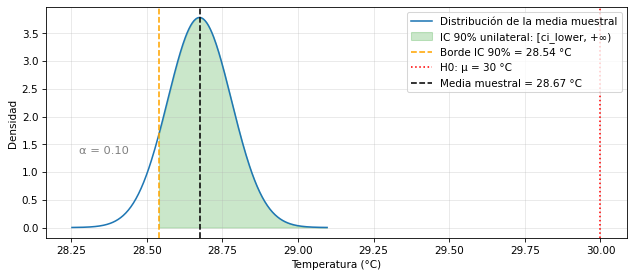

El gráfico posterior muestra el contraste de hipótesis, incluyendo la región crítica, el valor del estadístico t y el valor de mu = 30 considerado en la hipótesis.
Tras un breve análisis, se observa que el valor mu = 30 se encuentra alejado de la media muestral estimada, lo que se refleja en la posición del estadístico dentro de la distribución.
Además, el estadístico t se sitúa fuera de la región crítica definida para el contraste, por lo que no se dispone de evidencia suficiente para rechazar la hipótesis nula.
En consecuencia, el gráfico confirma visualmente los resultados obtenidos analíticamente.


In [3]:
mu0 = 30
x = np.linspace(xbar - 4 * se, xbar + 4 * se, 300)
y = stats.t.pdf((x - xbar) / se, df=n-1) / se

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Distribución de la media muestral', color='tab:blue')
plt.fill_between(x, y, where=(x >= ci_lower), color='tab:green', alpha=0.25, label='IC 90% unilateral: [ci_lower, +∞)')
plt.axvline(ci_lower, color='orange', linestyle='--', label=f'Borde IC 90% = {ci_lower:.2f} °C')
plt.axvline(mu0, color='red', linestyle=':', label=f'H0: μ = {mu0:.0f} °C')
plt.axvline(xbar, color='k', linestyle='--', label=f'Media muestral = {xbar:.2f} °C')
plt.text(ci_lower - 2.5 * se, max(y) * 0.35, 'α = 0.10', color='gray', fontsize=11)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.1： Distribución t y región crítica del contraste unilateral H1 mu mayor que 30 °C de la temperatura en la celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

print("El gráfico posterior muestra el contraste de hipótesis, incluyendo la región crítica, el valor del estadístico t y el valor de mu = 30 considerado en la hipótesis.\n"
      "Tras un breve análisis, se observa que el valor mu = 30 se encuentra alejado de la media muestral estimada, lo que se refleja en la posición del estadístico dentro de la distribución.\n"
      "Además, el estadístico t se sitúa fuera de la región crítica definida para el contraste, por lo que no se dispone de evidencia suficiente para rechazar la hipótesis nula.\n"
      "En consecuencia, el gráfico confirma visualmente los resultados obtenidos analíticamente.")

## 1.2. Contraste para la afirmación del analista 2 (media inferior a 30 °C)

Una meteoróloga afirma que la temperatura media estival (junio-agosto) en la celda 01 es exactamente 30 °C. El analista 2 sostiene que la media real es significativamente inferior a 30 °C.

Plantea el contraste paramétrico correspondiente con nivel de confianza del 90% (asumiendo normalidad), indica hipótesis nula y alternativa, y concluye.

In [4]:
df_orig_temp['FECHA'] = pd.to_datetime(df_orig_temp['FECHA'])
summer = df_orig_temp[df_orig_temp['FECHA'].dt.month.isin([6, 7, 8])]
temp01 = summer['TEMP_CELDA01'].dropna()

n = temp01.size
xbar = temp01.mean()
s = temp01.std(ddof=1)
se = s / np.sqrt(n)

beta = 0.90
alpha = 1 - beta

t_stat = (xbar - 30) / se
p_value_one_sided = stats.t.cdf(t_stat, df=n-1)
critical_t = stats.t.ppf(alpha, df=n-1)
ci_upper = xbar - critical_t * se

print('Observaciones de verano (junio-agosto):', n)
print('Media de TEMP_CELDA01 en verano:', xbar)
print('Desviación estándar muestral:', s)
print('Error estándar de la media:', se)
print('t estadístico:', t_stat)
print('t crítico unilateral 90%:', critical_t)
print('Límite superior del IC unilateral 90% para μ:', ci_upper)
print('p-valor unilateral (H1: mu < 30):', p_value_one_sided)
print('Decisión sobre H0:', 'rechazar H0' if p_value_one_sided < alpha else 'no rechazar H0')
print("")

print("En este segundo contraste, se plantea el contraste unilateral H0: mu = 30 frente a H1: mu < 30 utilizando la misma muestra que en el caso anterior. \n"
      "Dado que la media muestral y el error estándar coinciden con los obtenidos previamente, el cambio en la conclusión se debe únicamente a la dirección del contraste planteado. \n"
      "El estadístico t calculado es negativo, lo que indica que la media muestral se encuentra por debajo del valor de referencia. En este caso, dicha desviación se produce en la dirección considerada por la hipótesis alternativa. \n"
      "Como consecuencia, el estadístico se sitúa dentro de la región crítica del contraste y el p-valor unilateral resulta prácticamente nulo, proporcionando una evidencia estadística muy fuerte en contra de la hipótesis nula. \n"
      "En conclusión, se rechaza la hipótesis nula y se concluye que la media poblacional es significativamente inferior a 30.")

Observaciones de verano (junio-agosto): 1104
Media de TEMP_CELDA01 en verano: 28.674606713768114
Desviación estándar muestral: 3.502794839578006
Error estándar de la media: 0.10542173623675707
t estadístico: -12.572296127387869
t crítico unilateral 90%: -1.2823195642386653
Límite superior del IC unilateral 90% para μ: 28.809791068640514
p-valor unilateral (H1: mu < 30): 2.830780323494714e-34
Decisión sobre H0: rechazar H0

En este segundo contraste, se plantea el contraste unilateral H0: mu = 30 frente a H1: mu < 30 utilizando la misma muestra que en el caso anterior. 
Dado que la media muestral y el error estándar coinciden con los obtenidos previamente, el cambio en la conclusión se debe únicamente a la dirección del contraste planteado. 
El estadístico t calculado es negativo, lo que indica que la media muestral se encuentra por debajo del valor de referencia. En este caso, dicha desviación se produce en la dirección considerada por la hipótesis alternativa. 
Como consecuencia, el e

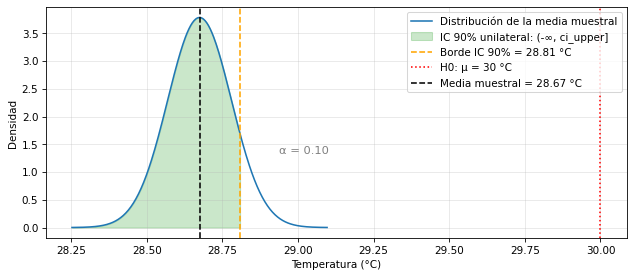

El gráfico representa la distribución del estimador de la media muestral junto con el intervalo de confianza unilateral del 90 por ciento para el contraste H1: mu < 30. 
Se observa que la media muestral se sitúa claramente a la izquierda del valor de referencia mu = 30, lo que indica que la estimación obtenida es inferior al valor planteado en la hipótesis nula. 
Además, el valor mu = 30 queda fuera del intervalo de confianza unilateral, ya que se encuentra a la derecha del límite superior representado en el gráfico. 
Esto confirma visualmente que la desviación observada es estadísticamente significativa en la dirección considerada por el contraste. 
En conclusión, el gráfico refuerza el resultado analítico, mostrando que existen evidencias suficientes para rechazar la hipótesis nula y concluir que la media es inferior a 30.


In [5]:
mu0 = 30
x = np.linspace(xbar - 4 * se, xbar + 4 * se, 300)
y = stats.t.pdf((x - xbar) / se, df=n-1) / se

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Distribución de la media muestral', color='tab:blue')
plt.fill_between(x, y, where=(x <= ci_upper), color='tab:green', alpha=0.25, label='IC 90% unilateral: (-∞, ci_upper]')
plt.axvline(ci_upper, color='orange', linestyle='--', label=f'Borde IC 90% = {ci_upper:.2f} °C')
plt.axvline(mu0, color='red', linestyle=':', label=f'H0: μ = {mu0:.0f} °C')
plt.axvline(xbar, color='k', linestyle='--', label=f'Media muestral = {xbar:.2f} °C')
plt.text(ci_upper + 1.2 * se, max(y) * 0.35, 'α = 0.10', color='gray', fontsize=11)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(IMAGES_DIR / 'Gráfico 1.2： Distribución t e intervalo de confianza unilateral del contraste H1 mu menor que 30 °C de la temperatura en la celda 01.png', dpi=300, bbox_inches='tight')
plt.show()

print("El gráfico representa la distribución del estimador de la media muestral junto con el intervalo de confianza unilateral del 90 por ciento para el contraste H1: mu < 30. \n"
      "Se observa que la media muestral se sitúa claramente a la izquierda del valor de referencia mu = 30, lo que indica que la estimación obtenida es inferior al valor planteado en la hipótesis nula. \n"
      "Además, el valor mu = 30 queda fuera del intervalo de confianza unilateral, ya que se encuentra a la derecha del límite superior representado en el gráfico. \n"
      "Esto confirma visualmente que la desviación observada es estadísticamente significativa en la dirección considerada por el contraste. \n"
      "En conclusión, el gráfico refuerza el resultado analítico, mostrando que existen evidencias suficientes para rechazar la hipótesis nula y concluir que la media es inferior a 30.")